# Dashboard Raw Close Price — Feature Engineering Analysis

This notebook visualizes feature importance scores from the dashboard models
(1d / 3d / 5d raw close-price prediction) to help decide how many features
to preserve for training via the `importance_top_k` config parameter.

Two-layer filtration pipeline:
1. **Pearson correlation filter** — remove redundant features (|corr| >= threshold)
2. **XGBoost gain importance** — rank surviving features, keep top-k

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config, load_model_config
from src.features.screening import (
    pearson_correlation_filter,
    xgboost_importance_filter,
)

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 6)})
print(f"Project root: {PROJECT_ROOT}")

Project root: c:\坐牢\ETF_strategy_prompt


## 1. Load Data

In [2]:
config_path = PROJECT_ROOT / "configs" / "china_open_universe_minimal.template.toml"
pipe_cfg = load_config(config_path)
model_cfg = load_model_config(config_path)
processed_dir = PROJECT_ROOT / pipe_cfg.processed_dir

# Load dashboard features and targets
feat_path = processed_dir / "dashboard_features.parquet"
tgt_path = processed_dir / "dashboard_targets.parquet"

if not feat_path.exists():
    print("ERROR: Run `python scripts/train_dashboard.py` first to generate dashboard_features.parquet")
else:
    dash_feat = pd.read_parquet(feat_path)
    dash_tgt = pd.read_parquet(tgt_path)
    print(f"Features: {dash_feat.shape}")
    print(f"Targets:  {dash_tgt.shape}")

    # Merge
    target_cols = [c for c in dash_tgt.columns if c.startswith("y_close_")]
    merged = dash_feat.merge(
        dash_tgt[["date", "symbol"] + target_cols],
        on=["date", "symbol"], how="inner",
    )
    feature_cols = sorted([c for c in dash_feat.columns if c not in ("date", "symbol", "close")])
    print(f"\nMerged: {merged.shape[0]} rows, {len(feature_cols)} features")
    print(f"Features: {feature_cols}")

Features: (24056, 50)
Targets:  (23984, 6)

Merged: 23984 rows, 47 features
Features: ['atr14_over_close', 'close_anchor', 'close_over_ma10', 'close_over_ma20', 'close_over_ma5', 'dow', 'dow_cos', 'dow_sin', 'dxy_ret_lag1', 'ema5_over_ema20', 'gap_oc_prev_close', 'hl_range_close', 'ieur_ret10d_lag1', 'ieur_ret_lag1', 'lower_shadow_pct', 'ma5_over_ma20', 'month', 'month_cos', 'month_sin', 'oc_body_pct', 'qqq_ret10d_lag1', 'qqq_ret_lag1', 'ret10_close', 'ret1_close', 'ret1_lag1', 'ret1_lag2', 'ret1_lag3', 'ret1_lag5', 'ret3_close', 'ret3_lag1', 'ret5_close', 'ret5_lag1', 'ret_accel_1v5', 'ret_accel_3v10', 'rv10_close', 'rv5_close', 'rv5_over_rv20', 'slope10_close', 'slope5_close', 'spy_ret10d_lag1', 'spy_ret_lag1', 'upper_shadow_pct', 'us10y_chg_lag1', 'vix_chg_lag1', 'vol_chg1', 'vol_ma_ratio20', 'vol_z20']


## 2. Pearson Correlation Matrix & Filter

In [3]:
fs_cfg = pipe_cfg.feature_selection

# Use y_close_1d as proxy target
sel_df = merged[feature_cols].copy()
sel_df["target"] = merged["y_close_1d"].values

# Stage A: Pearson correlation filter
surviving_feats, corr_matrix = pearson_correlation_filter(
    sel_df, feature_cols, target_col="target",
    threshold=fs_cfg.correlation_threshold,
    protected_prefixes=list(fs_cfg.protected_prefixes),
)

dropped_by_pearson = [c for c in feature_cols if c not in surviving_feats]
print(f"Pearson filter (threshold={fs_cfg.correlation_threshold}):")
print(f"  {len(feature_cols)} -> {len(surviving_feats)} features")
print(f"  Dropped: {dropped_by_pearson}")

Pearson filter (threshold=0.9):
  47 -> 40 features
  Dropped: ['close_over_ma20', 'ma5_over_ma20', 'ret3_close', 'ret5_close', 'ret_accel_1v5', 'spy_ret10d_lag1', 'spy_ret_lag1']


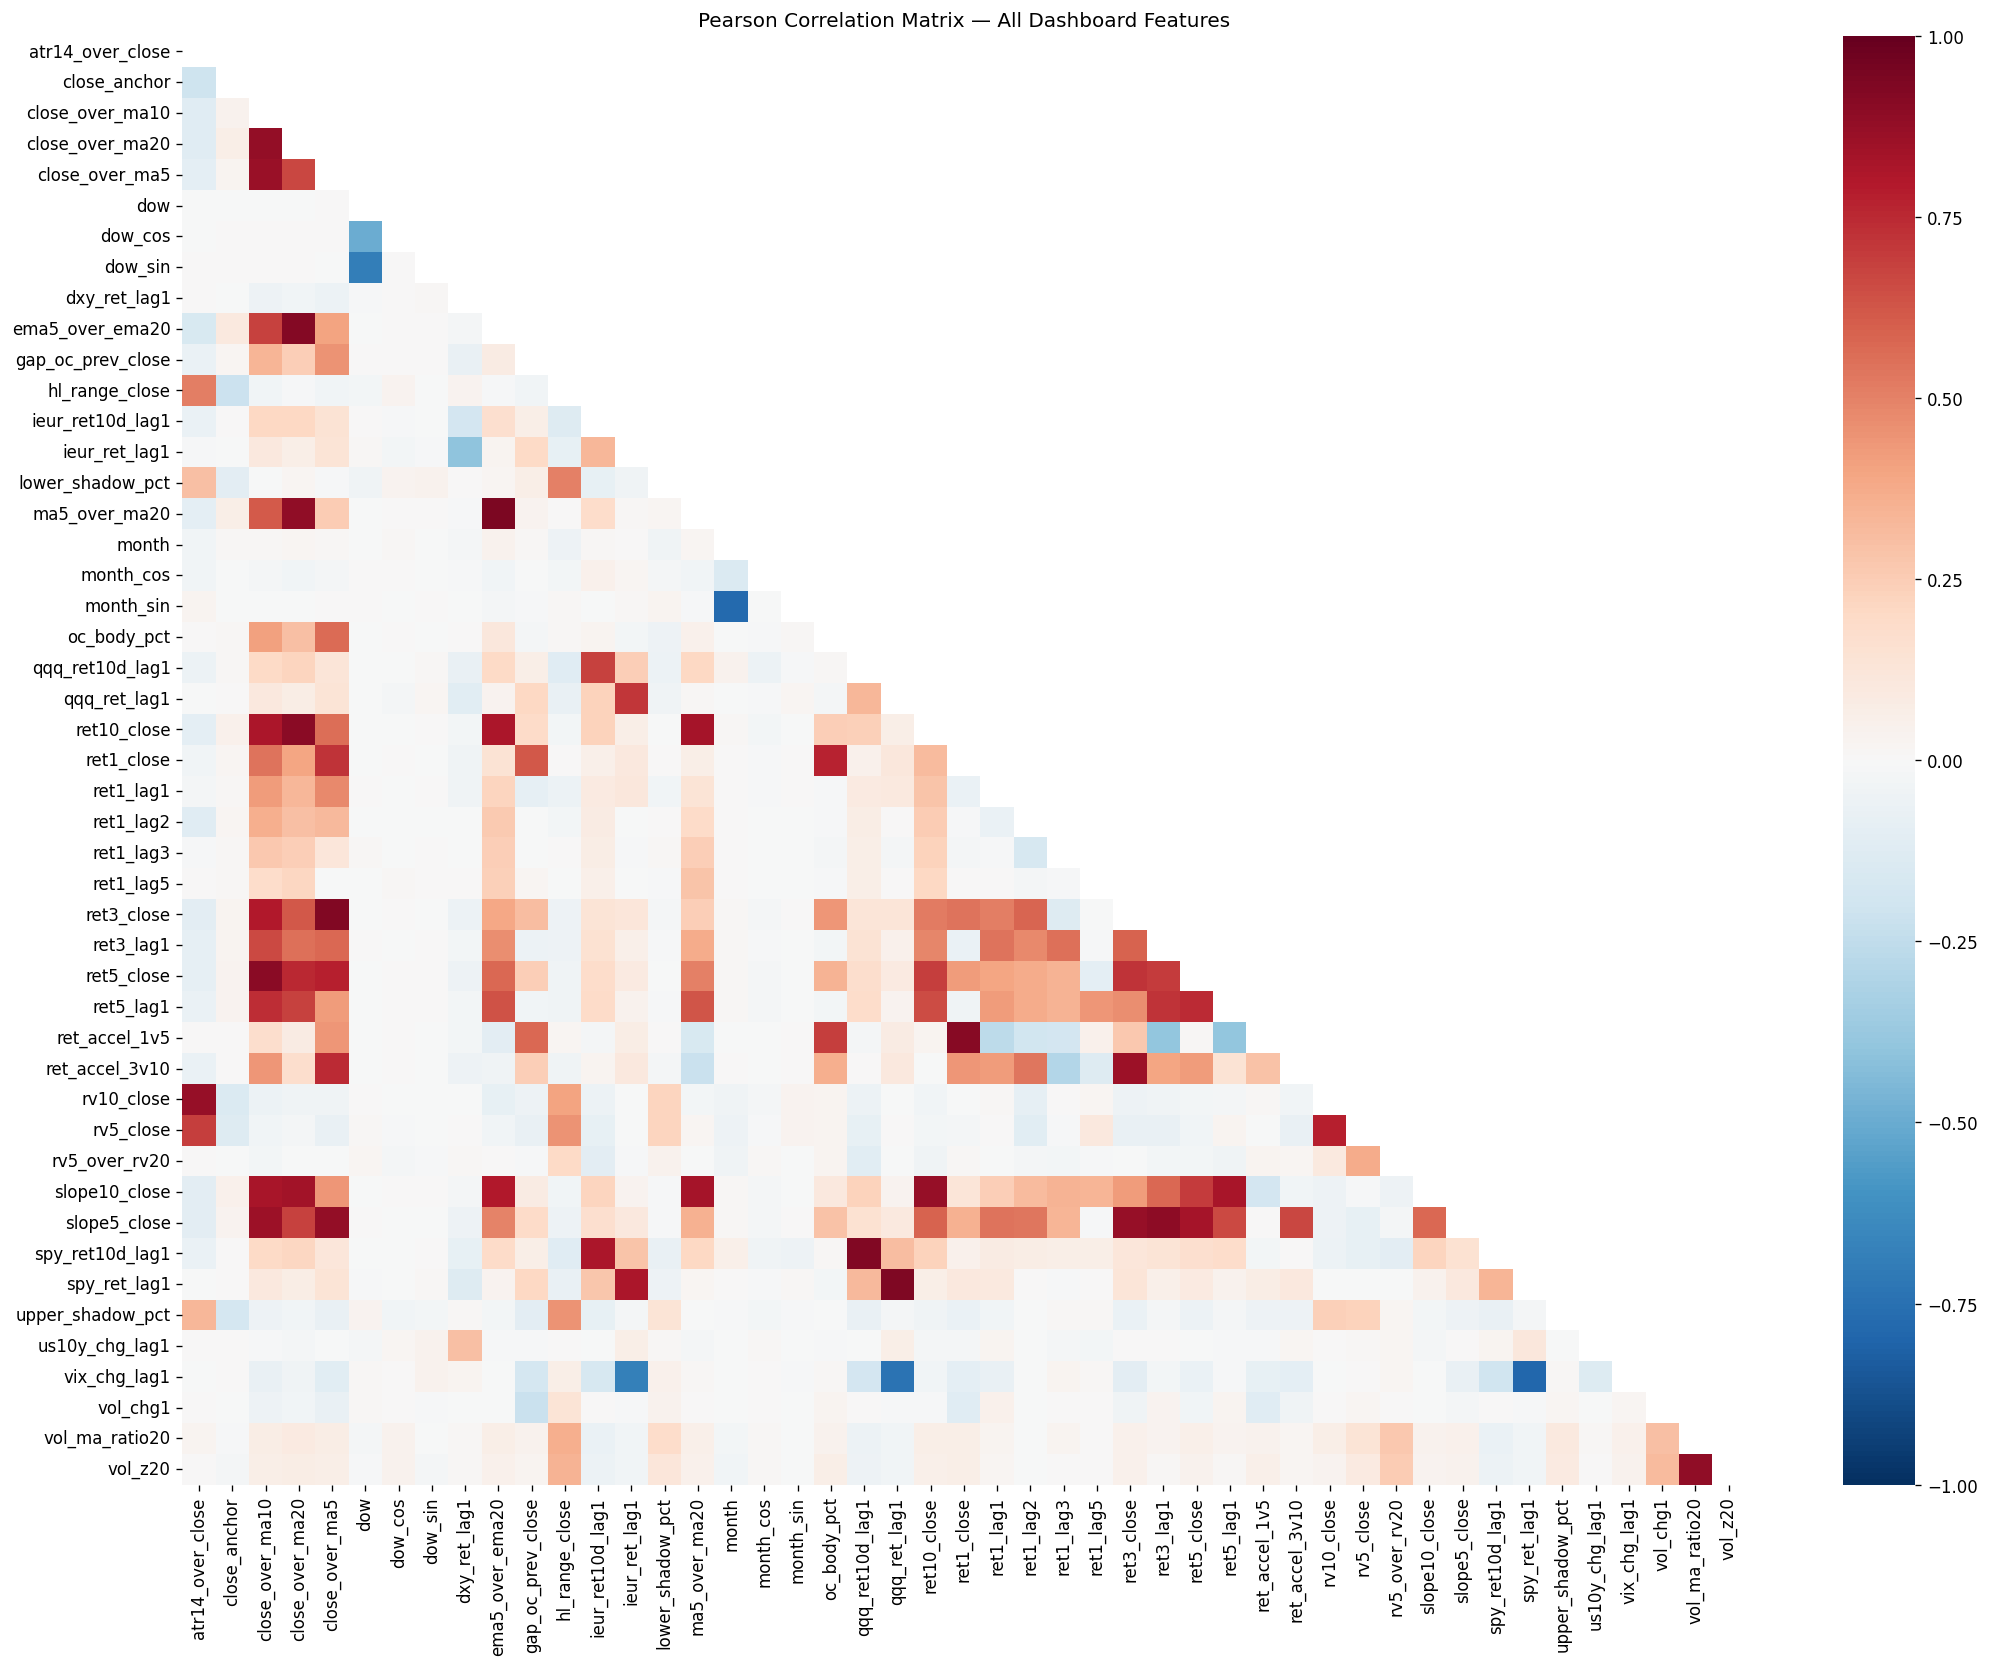

In [4]:
# Correlation heatmap (full feature set)
full_corr = merged[feature_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(full_corr, dtype=bool))
sns.heatmap(
    full_corr, mask=mask, cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, annot=False,
    xticklabels=True, yticklabels=True, ax=ax,
)
ax.set_title("Pearson Correlation Matrix — All Dashboard Features")
plt.tight_layout()
plt.show()

In [5]:
# Highlight highly correlated pairs (above 0.90)
high_corr_pairs = []
for i in range(len(full_corr.columns)):
    for j in range(i + 1, len(full_corr.columns)):
        val = full_corr.iloc[i, j]
        if abs(val) >= 0.90:
            high_corr_pairs.append((
                full_corr.columns[i], full_corr.columns[j], round(val, 3)
            ))

if high_corr_pairs:
    hc_df = pd.DataFrame(high_corr_pairs, columns=["Feature A", "Feature B", "Corr"])
    hc_df = hc_df.sort_values("Corr", key=abs, ascending=False)
    print(f"Highly correlated pairs (|corr| >= 0.90): {len(hc_df)}")
    display(hc_df)
else:
    print("No highly correlated pairs found (|corr| >= 0.90).")

Highly correlated pairs (|corr| >= 0.90): 7


,Feature A,Feature B,Corr
3,ema5_over_ema20,ma5_over_ma20,0.944
5,qqq_ret_lag1,spy_ret_lag1,0.936
2,close_over_ma5,ret3_close,0.925
4,qqq_ret10d_lag1,spy_ret10d_lag1,0.924
1,close_over_ma20,ema5_over_ema20,0.915
6,ret1_close,ret_accel_1v5,0.907
0,close_over_ma10,ret5_close,0.901


## 3. XGBoost Feature Importance Ranking

In [6]:
# Stage B: XGBoost importance (on post-Pearson feature set)
sel_df2 = merged[surviving_feats].copy()
sel_df2["target"] = merged["y_close_1d"].values

_, importance_series = xgboost_importance_filter(
    sel_df2, surviving_feats, target_col="target",
    top_k=None,  # rank only, no cutoff
    protected_prefixes=list(fs_cfg.protected_prefixes),
    seed=pipe_cfg.seed,
)

print(f"XGBoost importance ranking ({len(importance_series)} features):")
print(importance_series.to_string())

XGBoost importance ranking (40 features):
close_anchor         0.787703
atr14_over_close     0.042390
hl_range_close       0.026704
vol_z20              0.018365
gap_oc_prev_close    0.013068
month_sin            0.012761
ema5_over_ema20      0.011630
vol_ma_ratio20       0.010963
upper_shadow_pct     0.010437
month                0.008717
qqq_ret10d_lag1      0.007044
rv5_close            0.006462
rv10_close           0.005849
month_cos            0.004674
vol_chg1             0.004418
rv5_over_rv20        0.004291
ieur_ret10d_lag1     0.003886
ret10_close          0.003352
lower_shadow_pct     0.002639
oc_body_pct          0.002028
slope5_close         0.001952
close_over_ma10      0.001816
us10y_chg_lag1       0.001311
slope10_close        0.001309
close_over_ma5       0.001081
ret1_close           0.000634
dxy_ret_lag1         0.000480
ret3_lag1            0.000448
ret1_lag1            0.000439
ret1_lag3            0.000417
ieur_ret_lag1        0.000373
vix_chg_lag1         0.00036

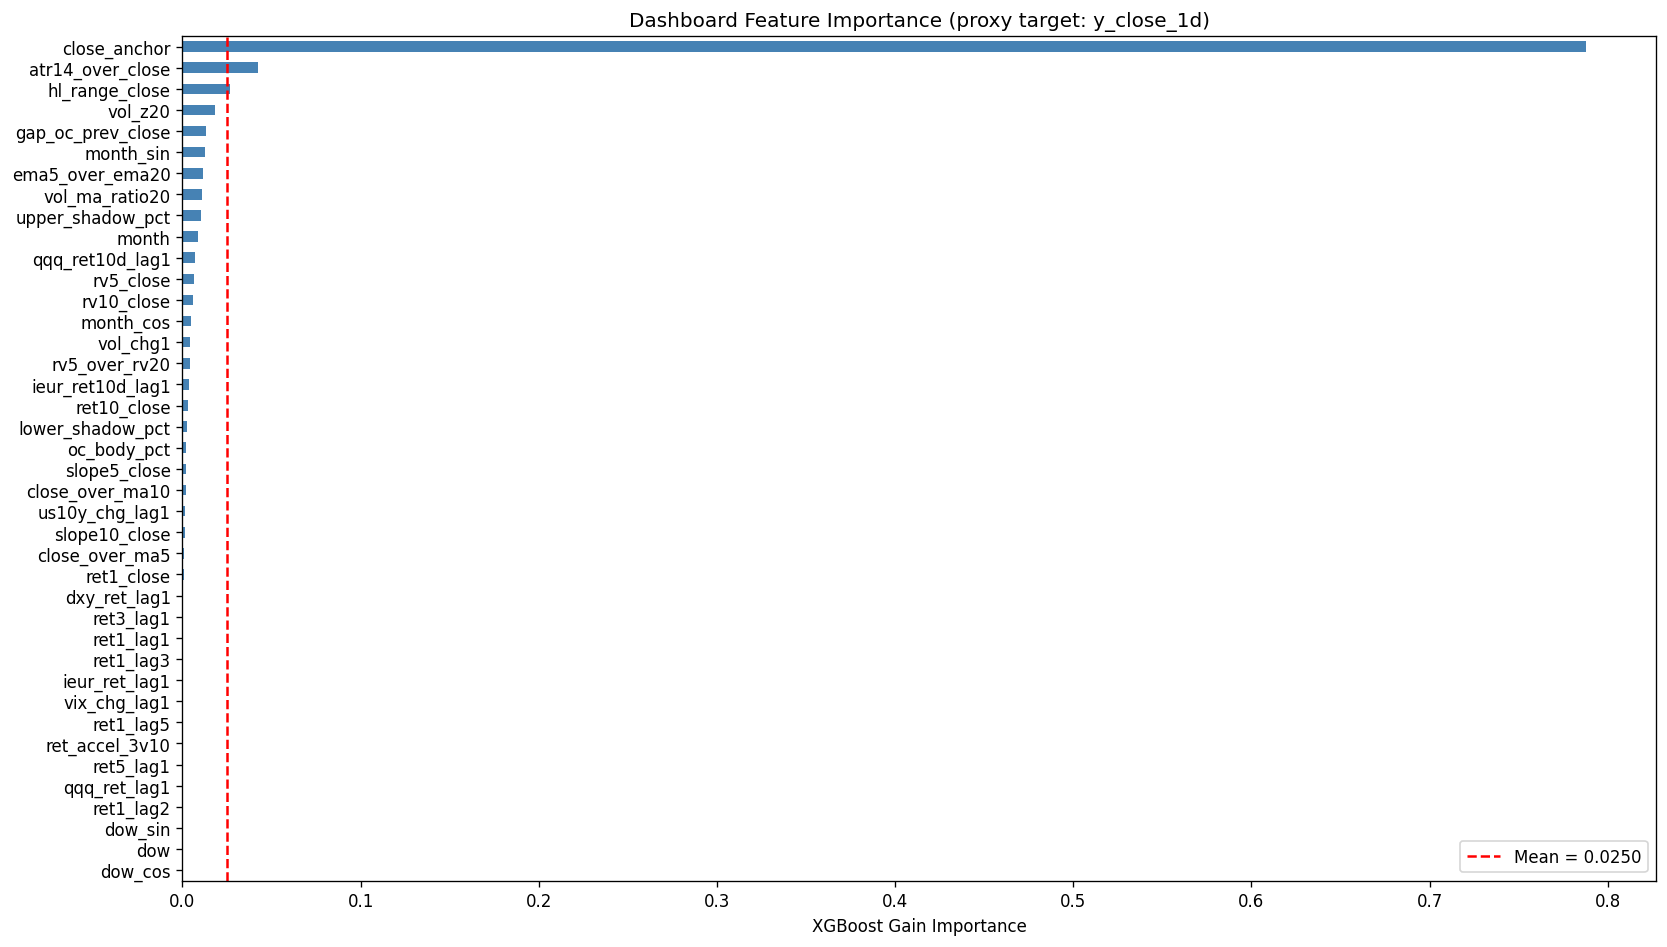

In [7]:
# Bar chart of feature importance (sorted descending)
fig, ax = plt.subplots(figsize=(14, 8))
importance_series.sort_values(ascending=True).plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("XGBoost Gain Importance")
ax.set_title("Dashboard Feature Importance (proxy target: y_close_1d)")
ax.axvline(x=importance_series.mean(), color="red", linestyle="--", label=f"Mean = {importance_series.mean():.4f}")
ax.legend()
plt.tight_layout()
plt.show()

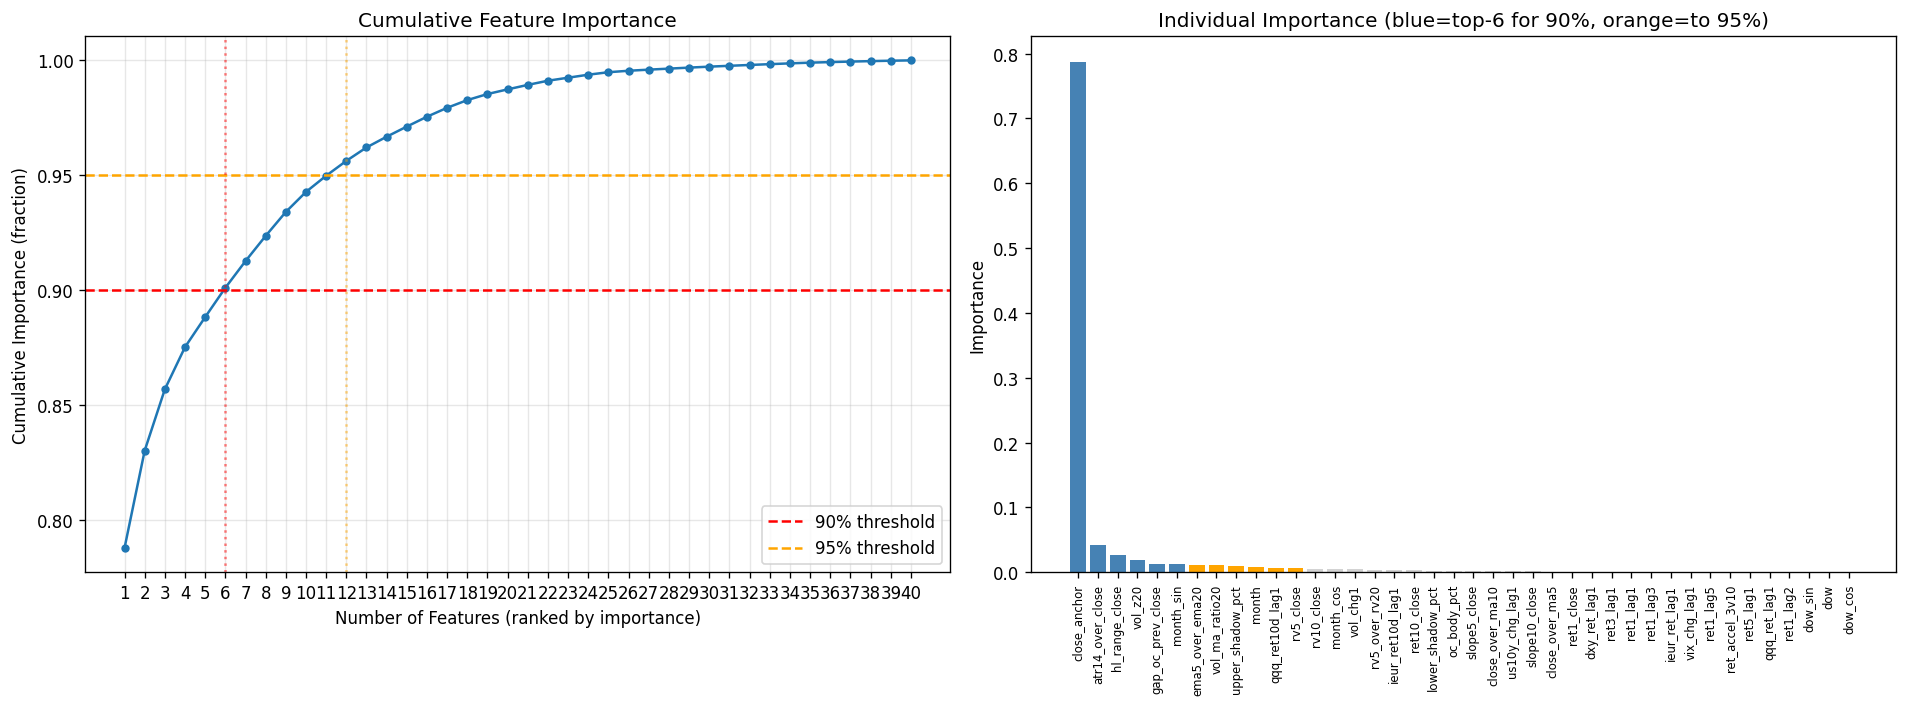


Features for 90% cumulative importance: top-6
Features for 95% cumulative importance: top-12
Total features available: 40


In [8]:
# Cumulative importance — helps decide top_k cutoff
sorted_imp = importance_series.sort_values(ascending=False)
cum_imp = sorted_imp.cumsum() / sorted_imp.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: cumulative importance curve
ax1 = axes[0]
ax1.plot(range(1, len(cum_imp) + 1), cum_imp.values, "o-", markersize=4)
ax1.axhline(y=0.90, color="red", linestyle="--", label="90% threshold")
ax1.axhline(y=0.95, color="orange", linestyle="--", label="95% threshold")
# Mark where 90% is reached
n_for_90 = int((cum_imp >= 0.90).argmax()) + 1
n_for_95 = int((cum_imp >= 0.95).argmax()) + 1
ax1.axvline(x=n_for_90, color="red", linestyle=":", alpha=0.5)
ax1.axvline(x=n_for_95, color="orange", linestyle=":", alpha=0.5)
ax1.set_xlabel("Number of Features (ranked by importance)")
ax1.set_ylabel("Cumulative Importance (fraction)")
ax1.set_title("Cumulative Feature Importance")
ax1.legend()
ax1.set_xticks(range(1, len(cum_imp) + 1))
ax1.grid(True, alpha=0.3)

# Right: individual importance with cutoff markers
ax2 = axes[1]
colors = ["steelblue" if i < n_for_90 else ("orange" if i < n_for_95 else "lightgray")
          for i in range(len(sorted_imp))]
ax2.bar(range(len(sorted_imp)), sorted_imp.values, color=colors)
ax2.set_xticks(range(len(sorted_imp)))
ax2.set_xticklabels(sorted_imp.index, rotation=90, fontsize=7)
ax2.set_ylabel("Importance")
ax2.set_title(f"Individual Importance (blue=top-{n_for_90} for 90%, orange=to 95%)")
plt.tight_layout()
plt.show()

print(f"\nFeatures for 90% cumulative importance: top-{n_for_90}")
print(f"Features for 95% cumulative importance: top-{n_for_95}")
print(f"Total features available: {len(sorted_imp)}")

## 4. Per-Horizon Importance Comparison (1d / 3d / 5d)

In [9]:
# Compute importance for each horizon separately
horizon_importance = {}
for tcol in target_cols:
    sel_h = merged[surviving_feats].copy()
    sel_h["target"] = merged[tcol].values
    _, imp_h = xgboost_importance_filter(
        sel_h, surviving_feats, target_col="target",
        top_k=None,
        protected_prefixes=list(fs_cfg.protected_prefixes),
        seed=pipe_cfg.seed,
    )
    horizon_importance[tcol] = imp_h

imp_df = pd.DataFrame(horizon_importance)
imp_df = imp_df.fillna(0)
print("Per-horizon importance:")
display(imp_df.sort_values(target_cols[0], ascending=False))

Per-horizon importance:


,y_close_1d,y_close_3d,y_close_5d
close_anchor,0.787703,0.781246,0.780563
atr14_over_close,0.042390,0.043178,0.043971
hl_range_close,0.026704,0.025788,0.021868
vol_z20,0.018365,0.015734,0.017878
gap_oc_prev_close,0.013068,0.019965,0.022079
month_sin,0.012761,0.010624,0.008524
ema5_over_ema20,0.011630,0.014031,0.013513
vol_ma_ratio20,0.010963,0.013223,0.013675
upper_shadow_pct,0.010437,0.011182,0.010952
month,0.008717,0.008453,0.008388


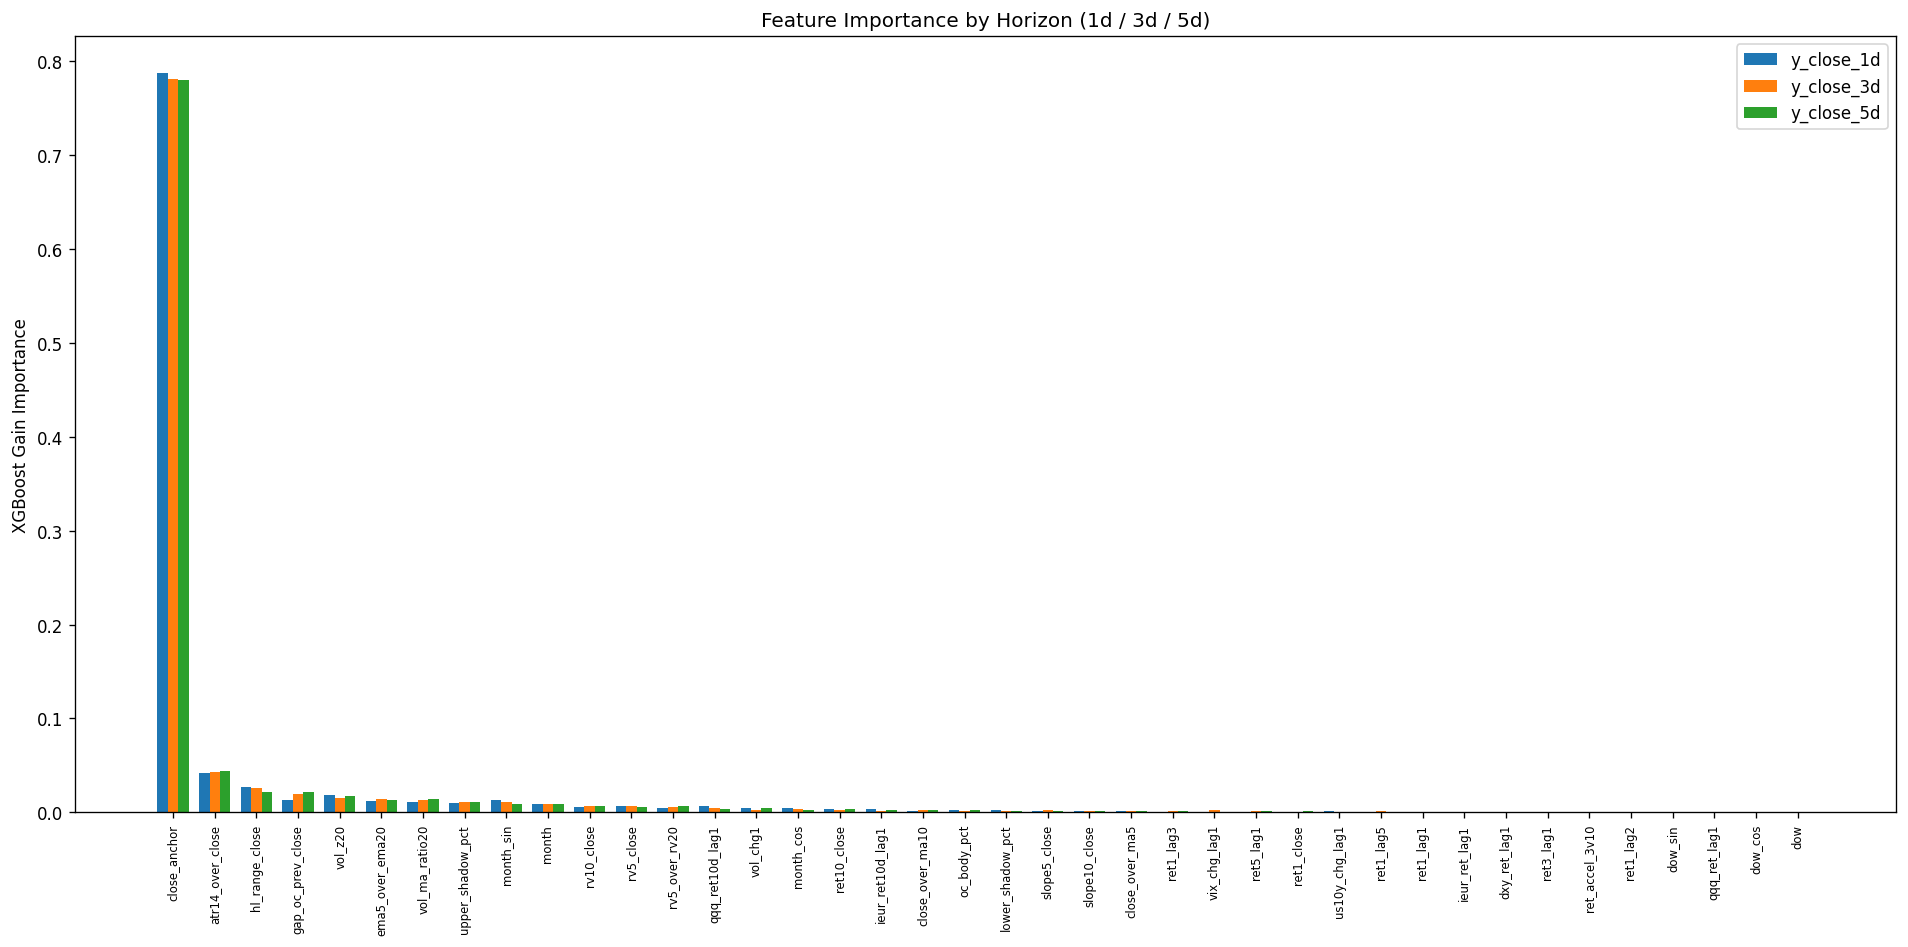

In [10]:
# Grouped bar chart: per-horizon importance comparison
imp_sorted = imp_df.loc[imp_df.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(16, 8))
x = np.arange(len(imp_sorted))
width = 0.25

for i, tcol in enumerate(target_cols):
    ax.bar(x + i * width, imp_sorted[tcol].values, width, label=tcol)

ax.set_xticks(x + width)
ax.set_xticklabels(imp_sorted.index, rotation=90, fontsize=7)
ax.set_ylabel("XGBoost Gain Importance")
ax.set_title("Feature Importance by Horizon (1d / 3d / 5d)")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Rank stability across horizons
rank_df = imp_df.rank(ascending=False)
rank_df.columns = [f"{c}_rank" for c in rank_df.columns]
rank_df["avg_rank"] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values("avg_rank")

print("Feature rank stability across horizons (lower avg = more consistently important):")
display(rank_df)

Feature rank stability across horizons (lower avg = more consistently important):


,y_close_1d_rank,y_close_3d_rank,y_close_5d_rank,avg_rank
close_anchor,1.0,1.0,1.0,1.000000
atr14_over_close,2.0,2.0,2.0,2.000000
hl_range_close,3.0,3.0,4.0,3.333333
gap_oc_prev_close,5.0,4.0,3.0,4.000000
vol_z20,4.0,5.0,5.0,4.666667
ema5_over_ema20,7.0,6.0,7.0,6.666667
vol_ma_ratio20,8.0,7.0,6.0,7.000000
month_sin,6.0,9.0,9.0,8.000000
upper_shadow_pct,9.0,8.0,8.0,8.333333
month,10.0,10.0,10.0,10.000000


## 5. Target Correlation with Features

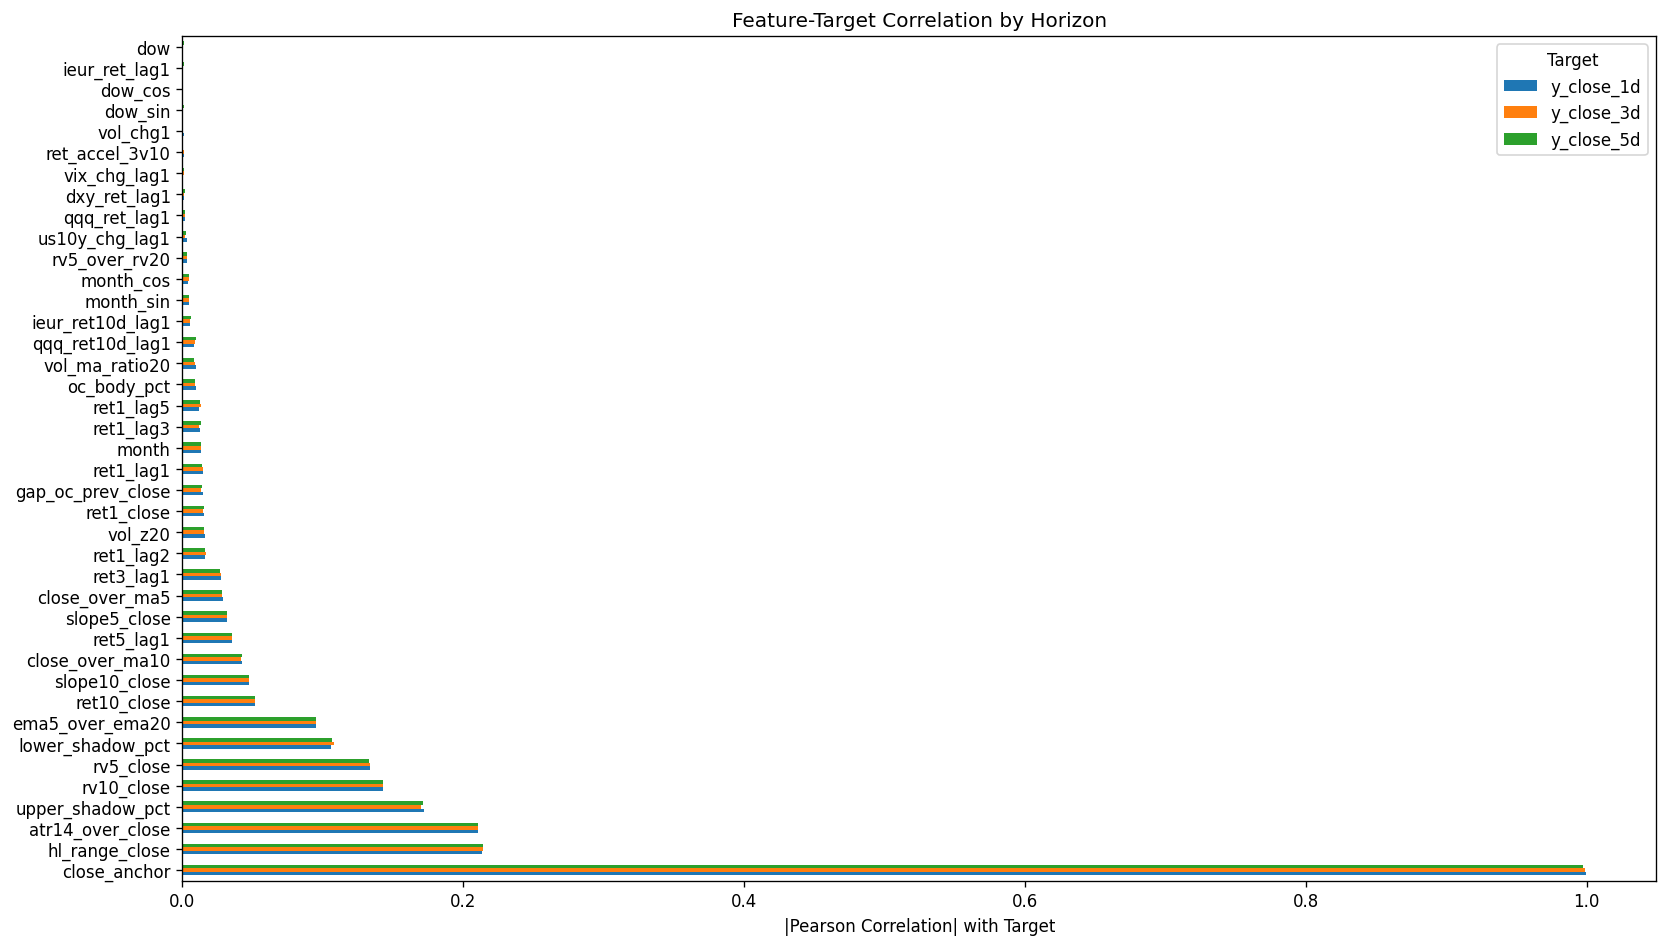

In [12]:
# Pearson correlation of each feature with each target
target_corrs = {}
for tcol in target_cols:
    target_corrs[tcol] = merged[surviving_feats].corrwith(merged[tcol]).abs()

tc_df = pd.DataFrame(target_corrs)

fig, ax = plt.subplots(figsize=(14, 8))
tc_sorted = tc_df.loc[tc_df.mean(axis=1).sort_values(ascending=False).index]
tc_sorted.plot.barh(ax=ax)
ax.set_xlabel("|Pearson Correlation| with Target")
ax.set_title("Feature-Target Correlation by Horizon")
ax.legend(title="Target")
plt.tight_layout()
plt.show()

## 6. Recommendation Summary

Based on the cumulative importance analysis:
- Set `importance_top_k` in `configs/china_open_universe_minimal.template.toml` under `[features.selection]`
- Then re-run `python scripts/train_dashboard.py` to train with the reduced feature set

In [13]:
print("=" * 60)
print("RECOMMENDATION SUMMARY")
print("=" * 60)
print(f"\nTotal features (after Pearson filter): {len(surviving_feats)}")
print(f"Top-{n_for_90} features capture 90% of cumulative importance")
print(f"Top-{n_for_95} features capture 95% of cumulative importance")
print(f"\nTop-{n_for_90} features (90% threshold):")
for i, feat in enumerate(sorted_imp.index[:n_for_90]):
    print(f"  {i+1:2d}. {feat:30s} importance={sorted_imp[feat]:.4f}  cum={cum_imp.iloc[i]:.3f}")
print(f"\nTo apply: set importance_top_k = {n_for_90} in config TOML")

RECOMMENDATION SUMMARY

Total features (after Pearson filter): 40
Top-6 features capture 90% of cumulative importance
Top-12 features capture 95% of cumulative importance

Top-6 features (90% threshold):
   1. close_anchor                   importance=0.7877  cum=0.788
   2. atr14_over_close               importance=0.0424  cum=0.830
   3. hl_range_close                 importance=0.0267  cum=0.857
   4. vol_z20                        importance=0.0184  cum=0.875
   5. gap_oc_prev_close              importance=0.0131  cum=0.888
   6. month_sin                      importance=0.0128  cum=0.901

To apply: set importance_top_k = 6 in config TOML
